In [1]:
import torch
import torch.nn as nn
import torchvision
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

DEVICE = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'

VOC_CLASSES = [
    'aeroplane','bicycle','bird','boat','bottle','bus','car','cat','chair','cow',
    'diningtable','dog','horse','motorbike','person','pottedplant','sheep','sofa','train','tvmonitor',
]

ANCHORS = [
    [(116,90),(156,198),(373,326)],
    [(30,61),(62,45),(59,119)],
    [(10,13),(16,30),(33,23)],
]

COLORS = [
    "#0000ff","#fd3d5a","#0037ff","#4800ff","#c300ff",
    "#00d0ff","#ff0000","#ff64fc","#000000","#7700ff",
    "#7700ff","#FF0000","#ff0000","#008CFF","#6a00ff",
    '#000075',"#ff0000","#ff0000","#000000",'#000000',
]
print(f'device={DEVICE}')


device=mps


In [2]:
def cb(ic, oc, k, s=1, p=0):
    return nn.Sequential(nn.Conv2d(ic,oc,k,s,p,bias=False), nn.BatchNorm2d(oc), nn.LeakyReLU(0.1,inplace=True))

class YOLOv1(nn.Module):
    def __init__(self, S=7, B=2, C=20):
        super().__init__()
        self.S=S; self.B=B; self.C=C
        gnet = torchvision.models.googlenet(weights='IMAGENET1K_V1')
        self.backbone = nn.Sequential(
            gnet.conv1, gnet.maxpool1, gnet.conv2, gnet.conv3, gnet.maxpool2,
            gnet.inception3a, gnet.inception3b, gnet.maxpool3,
            gnet.inception4a, gnet.inception4b, gnet.inception4c,
            gnet.inception4d, gnet.inception4e, gnet.maxpool4,
            gnet.inception5a, gnet.inception5b,
        )
        self.head = nn.Sequential(
            cb(1024,1024,3,p=1), cb(1024,1024,3,s=2,p=1),
            cb(1024,1024,3,p=1), cb(1024,1024,3,p=1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(1024*S*S,4096),
            nn.LeakyReLU(0.1,inplace=True), nn.Dropout(0.5),
            nn.Linear(4096, S*S*(B*5+C)),
        )
    def forward(self, x):
        return self.classifier(self.head(self.backbone(x))).reshape(-1,self.S,self.S,self.B*5+self.C)


def cbl(ic,oc,k=3,s=1,p=1):
    return nn.Sequential(nn.Conv2d(ic,oc,k,s,p,bias=False), nn.BatchNorm2d(oc), nn.LeakyReLU(0.01,inplace=True))

class Res(nn.Module):
    def __init__(self,c):
        super().__init__()
        self.b = nn.Sequential(cbl(c,c//2,1,1,0), cbl(c//2,c))
    def forward(self,x): return x+self.b(x)

def make5(ic,oc):
    return nn.Sequential(cbl(ic,oc,1,1,0),cbl(oc,oc*2),cbl(oc*2,oc,1,1,0),cbl(oc,oc*2),cbl(oc*2,oc,1,1,0))

class YOLOv3(nn.Module):
    def __init__(self,nc=20):
        super().__init__()
        out=3*(5+nc)
        self.d1=nn.Sequential(cbl(3,32),cbl(32,64,s=2),Res(64),cbl(64,128,s=2),Res(128),Res(128),cbl(128,256,s=2),*[Res(256) for _ in range(8)])
        self.d2=nn.Sequential(cbl(256,512,s=2),*[Res(512) for _ in range(8)])
        self.d3=nn.Sequential(cbl(512,1024,s=2),*[Res(1024) for _ in range(4)])
        self.c5_1=make5(1024,512); self.det1=nn.Sequential(cbl(512,1024),nn.Conv2d(1024,out,1))
        self.up2=nn.Sequential(cbl(512,256,1,1,0),nn.Upsample(scale_factor=2))
        self.c5_2=make5(768,256);  self.det2=nn.Sequential(cbl(256,512),nn.Conv2d(512,out,1))
        self.up3=nn.Sequential(cbl(256,128,1,1,0),nn.Upsample(scale_factor=2))
        self.c5_3=make5(384,128);  self.det3=nn.Sequential(cbl(128,256),nn.Conv2d(256,out,1))
    def forward(self,x):
        c3=self.d1(x); c4=self.d2(c3); c5=self.d3(c4)
        x1=self.c5_1(c5); o1=self.det1(x1)
        x2=self.c5_2(torch.cat([self.up2(x1),c4],1)); o2=self.det2(x2)
        x3=self.c5_3(torch.cat([self.up3(x2),c3],1)); o3=self.det3(x3)
        return o1,o2,o3


In [3]:
S, B, C = 7, 2, 20

v1 = YOLOv1(S, B, C).to(DEVICE)
v1.load_state_dict(torch.load('models/yolov1_best.pt', map_location=DEVICE))
v1.eval()
print('YOLOv1 loaded')

v3 = YOLOv3(nc=C).to(DEVICE)
v3.load_state_dict(torch.load('models/yolov3_voc_best.pt', map_location=DEVICE))
v3.eval()
print('YOLOv3 loaded')


YOLOv1 loaded
YOLOv3 loaded


In [4]:
def nms(boxes, scores, iou_thr=0.45):
    if boxes.shape[0] == 0: return []
    x1,y1,x2,y2 = boxes[:,0],boxes[:,1],boxes[:,2],boxes[:,3]
    areas = (x2-x1)*(y2-y1)
    order = scores.argsort(descending=True); keep=[]
    while order.numel():
        i=order[0].item(); keep.append(i)
        if order.numel()==1: break
        rest=order[1:]
        iw=(torch.min(x2[i],x2[rest])-torch.max(x1[i],x1[rest])).clamp(0)
        ih=(torch.min(y2[i],y2[rest])-torch.max(y1[i],y1[rest])).clamp(0)
        order=rest[iw*ih/(areas[i]+areas[rest]-iw*ih+1e-8)<=iou_thr]
    return keep


def decode_v1(pred, conf=0.25):
    gy,gx=torch.meshgrid(torch.arange(S,dtype=torch.float32),torch.arange(S,dtype=torch.float32),indexing='ij')
    boxes=pred[0,...,:B*5].reshape(S,S,B,5)
    cx=(torch.sigmoid(boxes[...,1])+gx[:,:,None])/S
    cy=(torch.sigmoid(boxes[...,2])+gy[:,:,None])/S
    w=torch.sigmoid(boxes[...,3]); h=torch.sigmoid(boxes[...,4])
    scores=torch.sigmoid(boxes[...,0]).unsqueeze(-1)*torch.softmax(pred[0,...,B*5:],-1).unsqueeze(2)
    max_sc,cls_id=scores.max(-1)
    mask=max_sc>conf
    bxyxy=torch.stack([cx[mask]-w[mask]/2,cy[mask]-h[mask]/2,cx[mask]+w[mask]/2,cy[mask]+h[mask]/2],-1)
    return bxyxy, max_sc[mask], cls_id[mask]


def decode_v3(out, anc, img_size, nc, conf=0.25):
    na=len(anc); G=out.shape[-1]
    a=torch.tensor(anc,dtype=torch.float32)/img_size
    p=out.view(1,na,5+nc,G,G).permute(0,1,3,4,2).contiguous()
    gy,gx=torch.meshgrid(torch.arange(G,dtype=torch.float32),torch.arange(G,dtype=torch.float32),indexing='ij')
    grid=torch.stack([gx,gy],-1).view(1,1,G,G,2)
    xy=(p[...,:2].sigmoid()+grid)/G
    wh=p[...,2:4].exp()*a.view(1,na,1,1,2)
    boxes=torch.cat([xy-wh/2,xy+wh/2],-1)
    s,ci=(p[...,4:5].sigmoid()*p[...,5:].sigmoid()).max(-1)
    mask=s.squeeze(0)>conf
    return boxes.squeeze(0)[mask], s.squeeze(0)[mask], ci.squeeze(0)[mask]


def apply_nms(pb, ps, pc, nc, iou_thr=0.45):
    keep=[]
    for cls in range(nc):
        m=(pc==cls)
        if not m.any(): continue
        idx=m.nonzero(as_tuple=True)[0]
        keep.extend(idx[nms(pb[idx],ps[idx],iou_thr)].tolist())
    return keep


def draw(ax, img, boxes, scores, cls_ids, class_names):
    W, H = img.size
    ax.imshow(img); ax.axis('off')
    for k in range(len(boxes)):
        x1,y1,x2,y2 = boxes[k].tolist()
        cls = int(cls_ids[k].item()) if hasattr(cls_ids[k],'item') else int(cls_ids[k])
        color = COLORS[cls % len(COLORS)]
        bx,by,bw,bh = x1*W, y1*H, (x2-x1)*W, (y2-y1)*H
        ax.add_patch(patches.Rectangle((bx,by),bw,bh,linewidth=2,edgecolor=color,facecolor='none'))
        label = f'{class_names[cls]}: {int(scores[k]*100)}%'
        ax.text(bx, by-2, label, fontsize=9, fontweight='bold', color='white',
                va='bottom', bbox=dict(facecolor=color, edgecolor='none', pad=2, alpha=1.0))


def predict(img_path, conf=0.6, iou=0.1):
    img = Image.open(img_path).convert('RGB')
    t448 = torch.from_numpy(np.array(img.resize((448,448)))).float().div(255).permute(2,0,1).unsqueeze(0).to(DEVICE)
    t416 = torch.from_numpy(np.array(img.resize((416,416)))).float().div(255).permute(2,0,1).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        pb1, ps1, pc1 = decode_v1(v1(t448).cpu(), conf)
        keep1 = apply_nms(pb1, ps1, pc1, C, iou)

        outs = v3(t416)
        pb3,ps3,pc3=[],[],[]
        for out,anc in zip(outs,ANCHORS):
            b,s,c=decode_v3(out.cpu(),anc,416,C,conf)
            pb3.append(b); ps3.append(s); pc3.append(c)
        pb3=torch.cat(pb3); ps3=torch.cat(ps3); pc3=torch.cat(pc3)
        keep3 = apply_nms(pb3,ps3,pc3,C,iou)

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    draw(axes[0], img, pb1[keep1], ps1[keep1], pc1[keep1], VOC_CLASSES)
    axes[0].set_title('YOLOv1', fontsize=13, pad=8)
    draw(axes[1], img, pb3[keep3], ps3[keep3], pc3[keep3], VOC_CLASSES)
    axes[1].set_title('YOLOv3', fontsize=13, pad=8)
    plt.tight_layout(); plt.show()


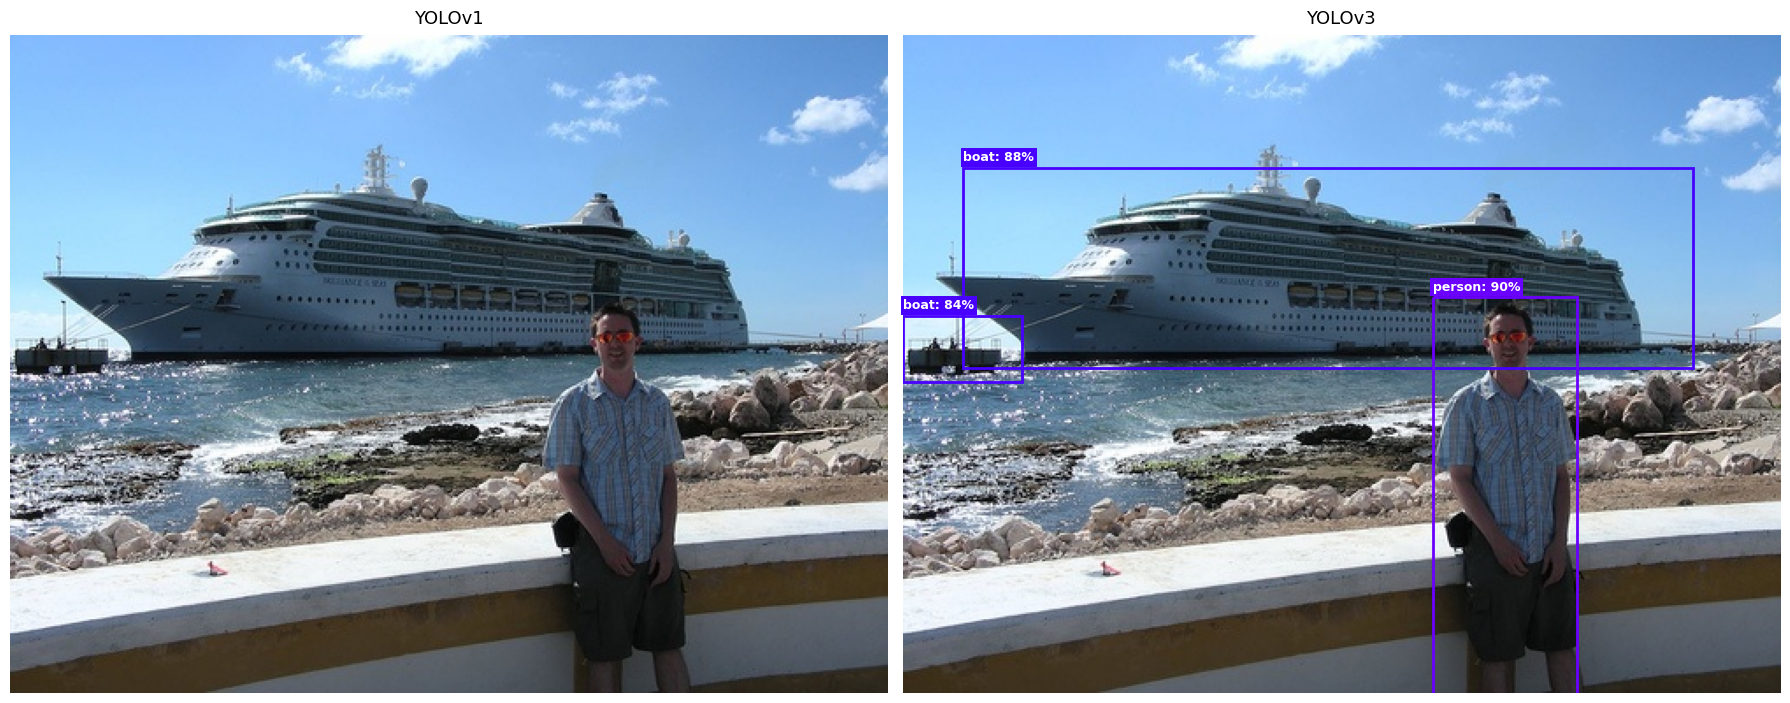

In [5]:
predict('data/VOC/VOC2007/JPEGImages/000069.jpg')
